# Option A — Real Photo CNN (ASL Alphabet Dataset)
Trains MobileNetV2 on real webcam-style hand photos at 64×64 RGB.
Dataset: https://www.kaggle.com/datasets/grassknoted/asl-alphabet (87k images, 29 classes)

Output: `models/optionA.tflite` — drop into `bonus/webcam_trials/models/`

## 1. Install & Imports

In [1]:
!pip install -q kaggle tensorflow

import os, random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

print('TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

2026-05-16 09:13:26.790345: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778922806.980715      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778922807.036043      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778922807.478616      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778922807.478652      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778922807.478655      23 computation_placer.cc:177] computation placer alr

TF: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Download Dataset

In [2]:
# Dataset is pre-mounted on Kaggle
TRAIN_DIR = "/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_train/asl_alphabet_train"
print("Classes:", sorted(os.listdir(TRAIN_DIR)))


Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


## 3. Config

In [3]:
IMG_SIZE   = 64       # 64Ã—64 RGB â€” 4Ã— more info than Sign MNIST 28Ã—28 gray
BATCH_SIZE = 64
EPOCHS     = 30
AUTOTUNE   = tf.data.AUTOTUNE

# Use A-Z only (exclude del, nothing, space) for ASL letter recognition
# J and Z are included â€” they appear as static poses in this dataset
ALL_CLASSES = sorted([c for c in os.listdir(TRAIN_DIR) if len(c) == 1 and c.isalpha()])
NUM_CLASSES = len(ALL_CLASSES)
CLASS_TO_IDX = {c: i for i, c in enumerate(ALL_CLASSES)}
print(f'Using {NUM_CLASSES} classes: {ALL_CLASSES}')

Using 26 classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


## 4. tf.data Pipeline with Augmentation

In [4]:
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label


augment_train = keras.Sequential([
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.12),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomFlip('horizontal'),      # mirror = same letter, different hand
    layers.RandomBrightness(0.15, value_range=(0, 1)),  # value_range=(0,1) for float images
    layers.RandomContrast(0.20),
], name='augment')


def augment_fn(img, label):
    img = augment_train(img, training=True)
    img = tf.clip_by_value(img, 0.0, 1.0)   # clamp after augmentation
    # small Gaussian noise
    if tf.random.uniform(()) < 0.3:
        img = tf.clip_by_value(
            img + tf.random.normal(tf.shape(img), stddev=0.02), 0.0, 1.0
        )
    return img, label


# Collect file paths and labels
all_paths, all_labels = [], []
for cls in ALL_CLASSES:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_paths.append(os.path.join(cls_dir, fname))
            all_labels.append(CLASS_TO_IDX[cls])

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)

# 90/10 split
idx      = np.random.permutation(len(all_paths))
split    = int(0.9 * len(idx))
tr_idx, val_idx = idx[:split], idx[split:]

def make_dataset(paths, labels, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if augment:
        ds = ds.shuffle(len(paths), seed=42)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

ds_train = make_dataset(all_paths[tr_idx],  all_labels[tr_idx],  augment=True)
ds_val   = make_dataset(all_paths[val_idx], all_labels[val_idx], augment=False)

print(f'Train: {len(tr_idx)} images  Val: {len(val_idx)} images')
print(f'Train batches: {len(ds_train)}  Val batches: {len(ds_val)}')

I0000 00:00:1778922831.623100      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Train: 70200 images  Val: 7800 images
Train batches: 1097  Val batches: 122


## 5. Sample Augmented Images

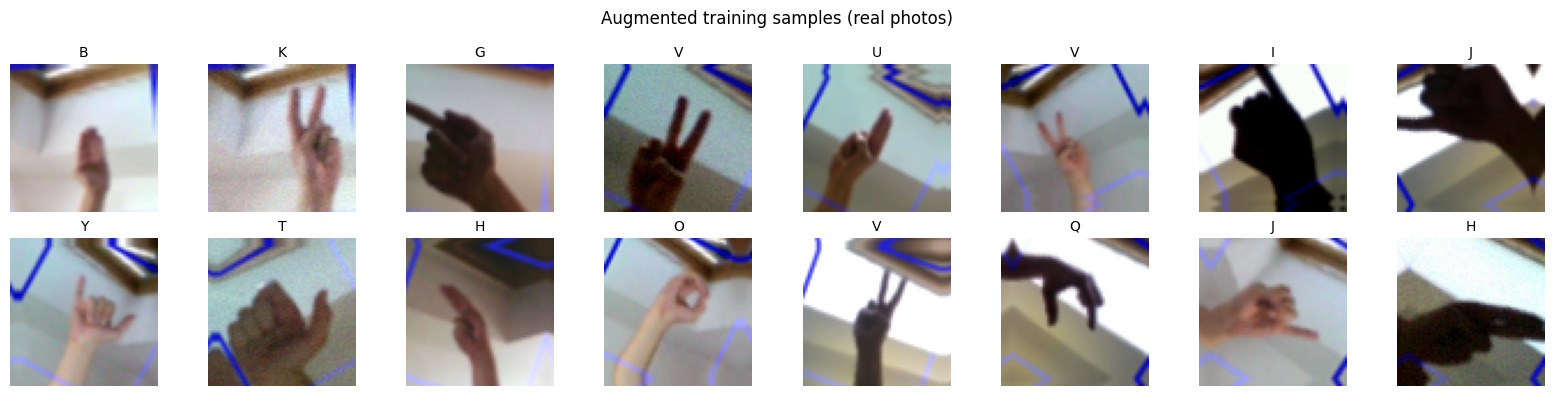

In [5]:
imgs, labels = next(iter(ds_train))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i].numpy())
    ax.set_title(ALL_CLASSES[labels[i]], fontsize=10)
    ax.axis('off')
plt.suptitle('Augmented training samples (real photos)')
plt.tight_layout()
plt.show()

## 6. Model — MobileNetV2 (transfer learning)

In [6]:
base = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
# Phase 1: freeze base, train head only
base.trainable = False

inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x   = base(inp, training=False)
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dropout(0.3)(x)
x   = layers.Dense(256, activation='relu')(x)
x   = layers.Dropout(0.4)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inp, out, name='OptionA_MobileNetV2')
model.summary()
print(f'Trainable params: {sum(p.numpy().size for p in model.trainable_variables):,}')

/tmp/ipykernel_23/1851220523.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "OptionA_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         6,682 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,602 (9.89 MB)

 Trainable params: 334,618 (1.28 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Trainable params: 334,618


## 7. Phase 1 — Train head (10 epochs)

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

h1 = model.fit(ds_train, epochs=10, validation_data=ds_val,
               callbacks=[keras.callbacks.EarlyStopping(
                   monitor='val_accuracy', patience=4, restore_best_weights=True)])

Epoch 1/10


I0000 00:00:1778922842.435559      72 service.cc:152] XLA service 0x7ef16000fce0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778922842.435623      72 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778922843.588930      72 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778922849.017631      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1097/1097 ━━━━━━━━━━━━━━━━━━━━ 207s 178ms/step - accuracy: 0.2652 - loss: 2.5496 - val_accuracy: 0.5373 - val_loss: 1.4866
Epoch 2/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 93s 85ms/step - accuracy: 0.4292 - loss: 1.8674 - val_accuracy: 0.5869 - val_loss: 1.3109
Epoch 3/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 92s 84ms/step - accuracy: 0.4586 - loss: 1.7634 - val_accuracy: 0.6054 - val_loss: 1.2548
Epoch 4/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 95s 87ms/step - accuracy: 0.4804 - loss: 1.6842 - val_accuracy: 0.6185 - val_loss: 1.2227
Epoch 5/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 93s 85ms/step - accuracy: 0.4889 - loss: 1.6408 - val_accuracy: 0.6467 - val_loss: 1.1517
Epoch 6/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 97s 88ms/step - accuracy: 0.4994 - loss: 1.6133 - val_accuracy: 0.6358 - val_loss: 1.1457
Epoch 7/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 95s 87ms/step - accuracy: 0.5013 - loss: 1.6058 - val_accuracy: 0.6427 - val_loss: 1.1342
Epoch 8/10
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 92s 84ms/step - accuracy: 0.5111 - loss: 1.

## 8. Phase 2 — Fine-tune top 50 layers

In [8]:
base.trainable = True
# Freeze all except last 50 layers
for layer in base.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),   # lower LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        '/kaggle/working/best_optionA.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
    ),
]

h2 = model.fit(ds_train, epochs=EPOCHS, validation_data=ds_val, callbacks=callbacks)

Epoch 1/30


2026-05-16 09:31:57.729107: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 09:31:57.938783: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 09:31:58.137334: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 09:31:58.321487: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1096/1097 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.3593 - loss: 2.3576

2026-05-16 09:33:40.182922: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 09:33:40.389602: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 09:33:40.588749: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 09:33:40.775466: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1097/1097 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.3595 - loss: 2.3570
Epoch 1: val_accuracy improved from -inf to 0.68167, saving model to /kaggle/working/best_optionA.keras
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 133s 102ms/step - accuracy: 0.3596 - loss: 2.3564 - val_accuracy: 0.6817 - val_loss: 1.1344 - learning_rate: 1.0000e-04
Epoch 2/30
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7071 - loss: 0.9041
Epoch 2: val_accuracy improved from 0.68167 to 0.84705, saving model to /kaggle/working/best_optionA.keras
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 100s 91ms/step - accuracy: 0.7071 - loss: 0.9040 - val_accuracy: 0.8471 - val_loss: 0.4494 - learning_rate: 1.0000e-04
Epoch 3/30
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.8077 - loss: 0.5795
Epoch 3: val_accuracy improved from 0.84705 to 0.89359, saving model to /kaggle/working/best_optionA.keras
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 102s 92ms/step - accuracy: 0.8077 - loss: 0.5794 - val_accuracy: 0.8936 - val_loss: 0.3075 - l

## 9. Evaluate

Val accuracy: 99.51%


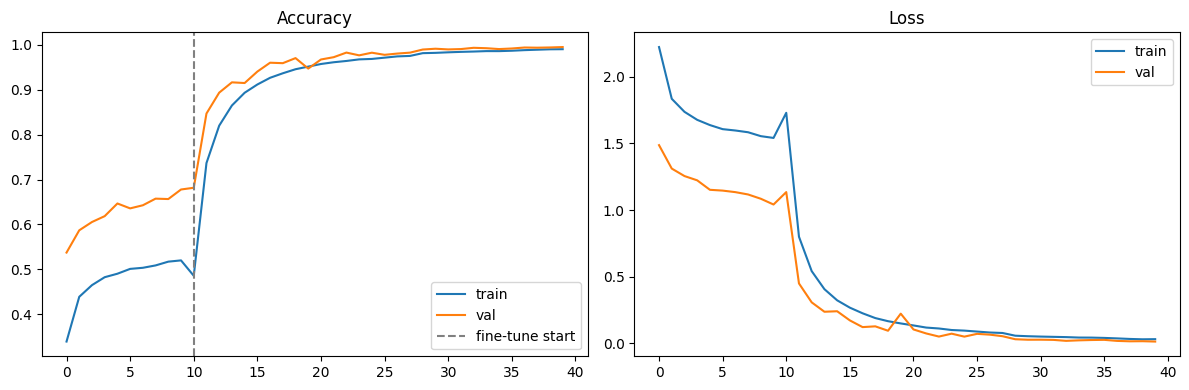

In [9]:
loss, acc = model.evaluate(ds_val, verbose=0)
print(f'Val accuracy: {acc*100:.2f}%')

all_h = {k: h1.history.get(k, []) + h2.history.get(k, []) for k in ['accuracy','val_accuracy','loss','val_loss']}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(all_h['accuracy'], label='train'); ax1.plot(all_h['val_accuracy'], label='val')
ax1.axvline(10, color='gray', linestyle='--', label='fine-tune start')
ax1.set_title('Accuracy'); ax1.legend()
ax2.plot(all_h['loss'], label='train'); ax2.plot(all_h['val_loss'], label='val')
ax2.set_title('Loss'); ax2.legend()
plt.tight_layout(); plt.show()

## 10. Export TFLite + Save classes

In [10]:
import json

# Save class list so Livestream.py knows the label mapping
with open('optionA_classes.json', 'w') as f:
    json.dump(ALL_CLASSES, f)
print('Classes:', ALL_CLASSES)

# Float32 TFLite
converter    = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('optionA.tflite', 'wb') as f:
    f.write(tflite_model)
print(f'FP32: {os.path.getsize("optionA.tflite")/1e6:.2f} MB')

Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
INFO:tensorflow:Assets written to: /tmp/tmp8cl4ire5/assets


INFO:tensorflow:Assets written to: /tmp/tmp8cl4ire5/assets


Saved artifact at '/tmp/tmp8cl4ire5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='keras_tensor_161')
Output Type:
  TensorSpec(shape=(None, 26), dtype=tf.float32, name=None)
Captures:
  139578649393872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139578649901776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139578649901968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139578649900816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139578649897744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139578649901008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139578649901584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139578649902544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139578649902928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139578649902160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13957864990

W0000 00:00:1778927080.195313      23 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778927080.195379      23 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1778927080.342432      23 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


## 11. Save Outputs

In [11]:
import shutil

OUT = "/kaggle/working"

shutil.copy("optionA.tflite",       os.path.join(OUT, "optionA.tflite"))
shutil.copy("optionA_classes.json", os.path.join(OUT, "optionA_classes.json"))
shutil.copy("best_optionA.keras",   os.path.join(OUT, "optionA.keras"))
print(f"Saved to {OUT}")
print("Next: download optionA.tflite → bonus/webcam_trials/models/optionA.tflite")


SameFileError: 'optionA.tflite' and '/kaggle/working/optionA.tflite' are the same file